# 1. Data Explorer

In [74]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import os
import helper_function as hp


data_path = Path("./data")
train_dir = Path(os.path.join("./data", "train"))
test_dir = Path(os.path.join("./data", "test"))
val_dir = Path(os.path.join("./data", "validation"))

device = "cuda" if torch.cuda.is_available() else "cpu"
device, test_dir, train_dir

('cpu', WindowsPath('data/test'), WindowsPath('data/train'))

In [3]:
hp.walk_through_dir("./data")

There are 4 directories and 0 images in './data'.
There are 0 directories and 1 images in './data\logs'.
There are 0 directories and 924 images in './data\test'.
There are 5 directories and 0 images in './data\train'.
There are 0 directories and 401 images in './data\train\daisy'.
There are 0 directories and 521 images in './data\train\dandelion'.
There are 0 directories and 404 images in './data\train\rose'.
There are 0 directories and 406 images in './data\train\sunflower'.
There are 0 directories and 503 images in './data\train\tulip'.
There are 5 directories and 0 images in './data\validation'.
There are 0 directories and 100 images in './data\validation\daisy'.
There are 0 directories and 123 images in './data\validation\dandelion'.
There are 0 directories and 93 images in './data\validation\rose'.
There are 0 directories and 89 images in './data\validation\sunflower'.
There are 0 directories and 100 images in './data\validation\tulip'.


## 1.1 Visualize some images


Let's write some code to:
1. Get all of the image paths using [`pathlib.Path.glob()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob) to find all of the files ending in `.jpg`. 
2. Pick a random image path using Python's [`random.choice()`](https://docs.python.org/3/library/random.html#random.choice).
3. Get the image class name using [`pathlib.Path.parent.stem`](https://docs.python.org/3/library/pathlib.html#pathlib.PurePath.parent).
4. And since we're working with images, we'll open the random image path using [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open) (PIL stands for Python Image Library).
5. We'll then show the image and print some metadata.

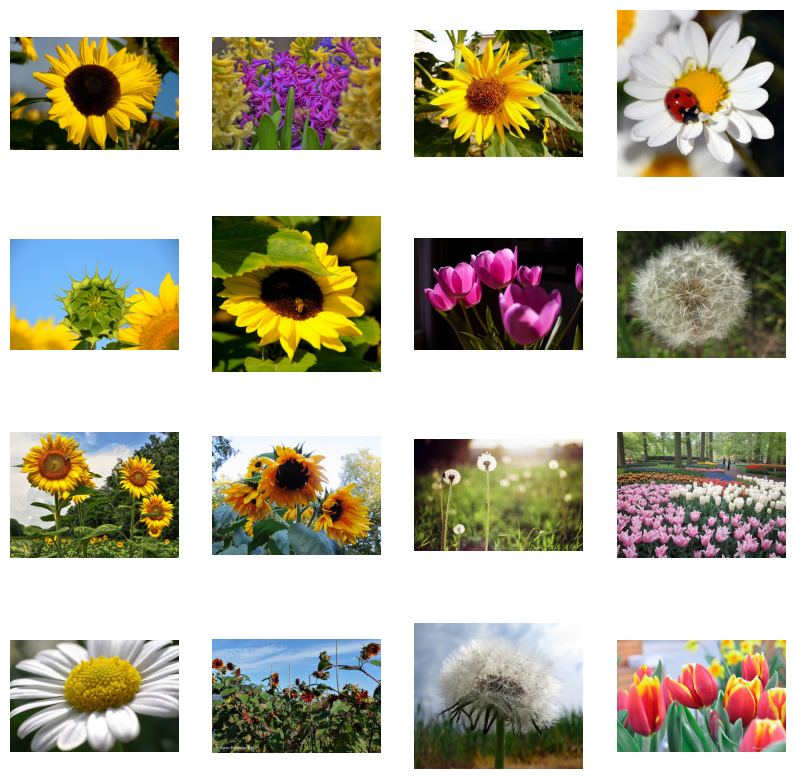

In [4]:
# set seed
# torch.manual_seed(2)

# 1. Get all image paths
image_path_list = list(data_path.glob("*/*/*.jpg"))

fig = plt.figure(figsize=(10, 10))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(image_path_list), size=(1,)).item()
    img_path = image_path_list[random_idx]
    img = Image.open(img_path)

    fig.add_subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
plt.show()


# 2. Check data transformation with **torchvision.transforms**

In [5]:
# Transform composed of a series of transforms to perform on an image
data_transform = transforms.Compose([
    # resize the image to 64x64
    transforms.Resize((64, 64)),
    # flip the image randomly on the horizontal with a probability of 0.5
    transforms.RandomHorizontalFlip(p=0.5),
    # random crop the image to 64x64
    transforms.RandomCrop(size=(64, 64)),
    # apply the TrivialAugmentWide data augmentation technique to the image
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    # convert the image to a tensor, this also scales the image's pixel values from 0-255 to 0-1
    transforms.ToTensor() 
])

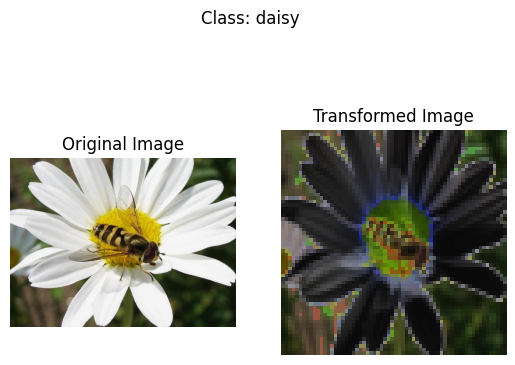

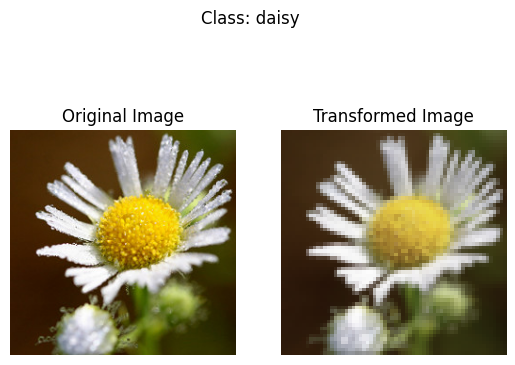

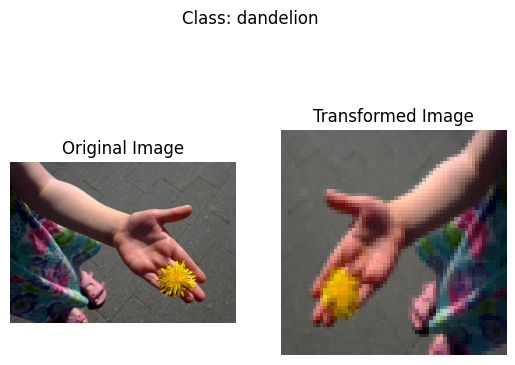

In [6]:
hp.plot_transformed_images(image_path_list, data_transform, n=3)

In [ ]:
# Find the class names in a target directory

class_names, class_names_idx = hp.find_class(os.path.join(data_path, "train"))
class_names, class_names_idx

(['daisy', 'dandelion', 'rose', 'sunflower', 'tulip'],
 {0: 'daisy', 1: 'dandelion', 2: 'rose', 3: 'sunflower', 4: 'tulip'})

# 3. **TinyVGG**

In [23]:

# Create model tinyVGG
from torch import nn

class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/

    Args: 
    input_shape: int
    hidden_unit: int
    ouptu_shape:int
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion



## 3.1 Creating transfoms without augmentation and loading data for Model 0

In [24]:
# ceate transforms for train and validation data
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# # Don't augment test data, only reshape
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [25]:
# 1. Loading data for training and testing
train_data_model_0 = hp.CustomImageDataset(train_dir, transform=simple_transform)
val_data = hp.CustomImageDataset(val_dir, transform=val_transforms)

# 2. Turn data into DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() 
# NUM_WORKERS = 0 # for CUDA
print(f"Creating dataloaders with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create dataloader's
train_dataloader_model_0 = DataLoader(train_data_model_0, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Creating dataloaders with batch size 32 and 8 workers.


## 3.2 Creating transfoms with augmentation and loading data for Model 1


In [26]:
# Create transformation

# Transform composed of a series of transforms to perform on an image
train_data_transform_m1 = transforms.Compose([
    # resize the image to 64x64
    transforms.Resize((64, 64)),
    # flip the image randomly on the horizontal with a probability of 0.5
    transforms.RandomHorizontalFlip(p=0.5),
    # random crop the image to 64x64
    transforms.RandomCrop(size=(64, 64)),
    # apply the TrivialAugmentWide data augmentation technique to the image
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    # convert the image to a tensor, this also scales the image's pixel values from 0-255 to 0-1
    transforms.ToTensor() 
])

In [31]:
# crate train dataset
train_data_model_1 = hp.CustomImageDataset(train_dir,train_data_transform_m1)

train_dataloader_model_1 = DataLoader(train_data_model_1, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

## 3.3 Train and Evaluate model **TinyVGG**

Replicate from https://poloclub.github.io/cnn-explainer/

### 3.3.1 Train model tinyVGG without augmentation (**MODEL 0**)

In [32]:

# Create model 0
torch.manual_seed(42)

model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_model_0.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=5, bias=True)
  )
)

In [28]:
# Use trochinfo to get an idea of the shapes going through our model
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary 

summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 5]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [ ]:
# Train model 0

# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_model_0.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = hp.train(model=model_0, 
                        train_dataloader=train_dataloader_model_0,
                        test_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
hp.save_model("model_0", model_0_results, model_0)

NameError: name 'model_0' is not defined

### 3.2.2 Train model TinyVGG with augumentation (**MODEL 1**)

In [ ]:
# create model 1

model_1 = TinyVGG(input_shape = 3,
                  hidden_units=10,
                 output_shape=len(train_data_model_1.classes)).to(device)



NameError: name 'TinyVGG' is not defined

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

start_time = timer()
model_1_results = hp.train(model=model_1, 
                        train_dataloader=train_dataloader_model_1,
                        test_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

end_time =  timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")
    

In [ ]:
hp.save_model("model_1", model_1_results, model_1)

# 4. Classification with **Timm**

In [94]:
# Create class for model (VIT or Efficientnet)

class BackboneExtractor(nn.Module):
    """
    Feature extractor supporting ViT-B/16 and EfficientNet-B4.

    Operation modes:
      - frozen   : The entire backbone is frozen, used for inference only.
      - finetune : Unfreezes the entire backbone for fine-tuning.
      - partial  : Unfreezes only the last N layers (effective for small datasets).

    Example:
        model = BackboneExtractor
        emb = model(batch_tensor)   
    """

    SUPPORTED = {
        'vit'         : 'hf-hub:timm/vit_base_patch16_dinov3_qkvb.lvd1689m',
        'efficientnet': 'hf-hub:timm/efficientnet_x_b5.sw_r448_e450_in1k'
    }

    def __init__(
        self, 
        backbone:str = 'vit',     # vit or efficientnet
        mode:str = 'frozen',      # 'frozen'| 'finetune' | 'partial'
        pretrained: bool = True,  # load weight ImageNet
        embed_dim:int = 512,      # image shape
        unfreeze_last_n: int = 2, # use when mode = 'partial'
        dropout: float = 0.1,
        oput_shape:int = 5
    ):
        super().__init__()

        if backbone not in self.SUPPORTED:
            raise ValueError(f"backbone is one in list {list(self.SUPPORTED)}")
        
        self.model = backbone
        self.mode = mode
        model = self.SUPPORTED[backbone]


        # ---Load backbone from timm----
        try:
            import timm
        except:
            !pip install timm
            import timm

        self.encoder = timm.create_model(
            model,
            pretrained= pretrained,
            num_classes = 0,
            global_pool = 'avg' if backbone == 'efficientnet' else 'token'
        )

        self.feature_dim = self.encoder.num_features

        # ---Projection head: feature_dim -> emded_dim ---
        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, embed_dim*2),
            nn.LayerNorm(embed_dim*2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*2, oput_shape),
        )

        # ---Apply forzen mode

        self._apply_freeze_mode(unfreeze_last_n,backbone)  
#---------------------------------------------------------------------------
    def _apply_freeze_mode(self,unfreeze_last_n:int, backbone) -> None:
        """ Open paramters based on mode"""

        if self.mode == 'frozen':
            # Freeze encoder, only train projector
            for param in self.encoder.parameters():
                param.requires_grad = False
            print(f"{backbone} frozen completely, only train on projector.")

        elif self.mode == 'finetune':
            # Unfreeze encoder
            for param in self.encoder.parameters():
                param.requires_grad = True
            print(f"{self.backbone} unfreeze completely, only train on projector.")
        
        elif self.mode == 'partial':
            # Freeze encoder first, the unfreeze N last layers
            for param in self.encoder.parameters():
                param.requires_grad = False
            
            # Get all layers that has paramete
            all_layer = [layer for layer in self.encoder.modules()
                         if list(layer.parameters(recurse=False))]
            
            layer_to_unfreeze = all_layer[-unfreeze_last_n:]
            for layer in layer_to_unfreeze:
                for param in layer.parameters():
                    param.requires_grad = True

            trainable = sum(p.numel() for p in self.encoder.parameters() if p.requires_grad)
            total     = sum(p.numel() for p in self.encoder.parameters())
            print(
                f"[Backbone] Partial fine-tune: mở {unfreeze_last_n} layer cuối. "
                f"Trainable encoder params: {trainable:,} / {total:,}"
            )
        else:
            raise ValueError(f"mode không hợp lệ: {self.mode}")
    

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: tensor ảnh, shape (B, 3, H, W), đã chuẩn hoá.

        Returns:
            embedding: shape (B, embed_dim), L2-normalised.
        """
        features = self.encoder(x)          # (B, feature_dim)
        embedding = self.projector(features) # (B, embed_dim)
        embedding = nn.functional.normalize(embedding, dim=-1)  # L2 norm
        return embedding

        

In [95]:
model_2 = BackboneExtractor('vit',mode ='frozen', pretrained=True, embed_dim=256,unfreeze_last_n=3, oput_shape=5)

vit frozen completely, only train on projector.


In [ ]:
# Train model 0

# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_model_0.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_2_results = hp.train(model=model_2, 
                        train_dataloader=train_dataloader_model_1,
                        test_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

In [ ]:
hp.save_model('model_2',model_2_results)